In [1]:
%reset -f 
%run func_defs.ipynb

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import CubicSpline
import math

torch.set_default_dtype(torch.float64)

In [3]:
def U0(z, t):
    z = torch.as_tensor(z, dtype=torch.float64)
    t = torch.as_tensor(t, dtype=torch.float64)
    sqrt_4t = torch.sqrt(4 * t)
    
    return (
        -torch.exp(-z)
        + 0.5 * torch.where(
            2 * t < z,
            torch.exp(-torch.abs(z - t)) * torch.erfc((2 * t - z) / sqrt_4t),
            torch.exp(-z**2 / (4 * t)) * torch.special.erfcx(torch.abs(2 * t - z) / sqrt_4t)
        )
        + 0.5 * torch.exp(-z**2 / (4 * t)) * torch.special.erfcx((2 * t + z) / sqrt_4t)
        - z * torch.erfc(z / sqrt_4t)
        + 2 * torch.sqrt(t / math.pi) * torch.exp(-z**2 / (4 * t))
    )

In [4]:
def set_BCs(T):
    T[0]  = T[2]
    T[-1] = T[-2] ** 2 / max(T[-3].item(), 1e-40)

def avg_2_center(T, m):
    Tc = T.clone()
    Tc[m] = (8*T[m]-T[m-1]-T[m+1])/6
    return Tc

def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True):
    """
    Solve the two-layer heat equation from t=0 to t=tf.
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz
    m  = torch.searchsorted(z, z_dis - 0.5 * dz, right=True).item()
    if verbose:
        print(f'device: {device},  nz={nz},  tf={tf},  M={M}')
        print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')
    k_iL = 8 * k1 * k2 / (k1 + 7 * k2)
    k_iR = 8 * k1 * k2 / (7 * k1 + k2)
    kh   = torch.where(
        z[:-1] < z_dis - 0.5 * dz,
        torch.tensor(k1, device=device),
        torch.tensor(k2, device=device),
    )
    kh[m - 1] = k_iL
    kh[m]     = k_iR
    
    dt_stab = 0.5 * (dz ** 2) / max(k1, k2)
    dt_want = tf/M
    nt_skip = int(np.ceil(dt_want/dt_stab))
    dt = dt_want/nt_skip
    dM = 8
    nt_num = (M+dM)*nt_skip
    delta   = nt_skip * dt
    t_out = torch.arange(0,M+dM+1)*delta
    U_out = torch.zeros(nz+1, M+dM+1, device=device)
    if verbose:
        print(f'dt_stab={dt_stab:.4e}  dt={dt:.4e}  nt_num={nt_num}  tf_num = {nt_num*dt}')
        print(f'nt_skip={nt_skip}  delta={delta:.6f}')
    
    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2]/4)
    T = torch.zeros(nz + 3, device=device)
    i_save = 0
    for step in range(1, nt_num+1):
        set_BCs(T)
        Jh      = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        if step % nt_skip == 0:
            i_save += 1
            U_out[:,i_save] = avg_2_center(T, m)[1:-1]
    set_BCs(T)
    T[m] = T[m] + (2 * T[m] - T[m - 1] - T[m + 1]) / 6
    print(f't_out.shape = {t_out.shape},  U_out.shape = {U_out.shape}\n')
    return {'z': z[1:-1], 't_out': t_out, 'U_out': U_out, 'nt_skip': nt_skip, 'delta': delta}

In [5]:
k1, k2  = 0.5, 1.0
z_dis   = 1.0
Pda     = 1.0
Lz      = 16
tf      = 12
device  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [6]:
%%time 
# Numerical Solution
nz = 320; M = 240
R = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True)
z_num = R['z']
t_num = R['t_out']
T_num = R['U_out']

device: cuda,  nz=320,  tf=12,  M=240
Interface alignment error: 0.00e+00
dt_stab=1.2500e-03  dt=1.2500e-03  nt_num=9920  tf_num = 12.4
nt_skip=40  delta=0.050000
t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

CPU times: user 3.5 s, sys: 264 ms, total: 3.77 s
Wall time: 3.78 s


In [7]:
print('='*80)
print('TRAINING DATA GENERATION  (nested Sobol, per handwritten notes)')
print(f'ALL DATA ON: {device}')
print('='*80)

from torch.quasirandom import SobolEngine

# ---- Outer parameter box (k1, z_d) ----
k1_lo, k1_hi = 0.5, 1.0
zd_lo, zd_hi = 0.5, 2.0

# ---- Inner (s, tau) box with margins so mapped (Z, t) stays strictly inside ----
#   s   axis:  s in [e^{-Lz}, 1]         ->  Z = -log(s) in [0, Lz]
#   tau axis:  tau = 1/(1+t)             ->  t = (1-tau)/tau
#              tau_lo = 1/(1+tf)  (t = tf, bottom edge)
#              tau_hi = 1/(1+t_min) (t = t_min, top edge)
t_min = 1e-4                              # smallest training time (from notes box)
s_lo,  s_hi  = np.exp(-Lz), 1.0
tau_lo = 1.0 / (1.0 + tf)                # -> t = tf
tau_hi = 1.0 / (1.0 + t_min)            # -> t = t_min

# ---- Sample counts (from notes) ----
N_OUTER = 10      # Sobol points in (k1, z_d)
N_INNER = 2048     # Sobol points in (s, tau) per outer point, fresh seed each
nz = 320; M = 240  # solver resolution per (k1, z_d)

print(f'outer (k1,z_d): {N_OUTER}   inner (s,tau): {N_INNER}   -> {N_OUTER*N_INNER:,} rows')

TRAINING DATA GENERATION  (nested Sobol, per handwritten notes)
ALL DATA ON: cuda
outer (k1,z_d): 10   inner (s,tau): 2048   -> 20,480 rows


In [8]:
def sample_s_tau(n_st, seed, device):
    """Joint Sobol sample in (s, tau); return mapped (Z, t) and raw (s, tau).

    Scrambled Sobol keeps points strictly inside the margins (never on the
    boundary), which is what the notes call for. A different seed each call
    decorrelates the inner clouds across outer points.
    """
    sob = SobolEngine(dimension=2, scramble=True, seed=seed)
    u   = sob.draw(n_st, dtype=torch.float64).to(device)      # in [0,1)^2

    s   = s_lo   + (s_hi   - s_lo)   * u[:, 0]
    tau = tau_lo + (tau_hi - tau_lo) * u[:, 1]

    Z = -torch.log(s)                    # in (0, Lz)
    t = (1.0 - tau) / tau                # in (t_min, tf)
    return Z, t, s, tau


def sample_k1_zd(n_outer, seed, device):
    """Sobol sample in (k1, z_d)."""
    sob = SobolEngine(dimension=2, scramble=True, seed=seed)
    u   = sob.draw(n_outer, dtype=torch.float64).to(device)
    k1_s = k1_lo + (k1_hi - k1_lo) * u[:, 0]
    zd_s = zd_lo + (zd_hi - zd_lo) * u[:, 1]
    return k1_s, zd_s

In [9]:
def smooth_U(U, z, z_dis, k1, k2):
    """Rescale z < z_dis to enforce the flux interface condition. (grid version)"""
    alpha    = k1 / k2
    m        = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()
    m        = min(m, z.shape[0] - 1)          # guard: keep m a valid row index
    U_smooth = U.clone()
    U_smooth[:m, :] = U[m, :] + alpha * (U[:m, :] - U[m, :])
    return U_smooth


def smooth_U_points(U_pts, Z_pts, T_pts, interp_pw, z_dis, k1, k2):
    """Scattered-point version of smooth_U.

    For query points with Z < z_dis, rescale toward the interface value
    U(z_dis, t) using the same flux condition alpha = k1/k2:
        U_smooth = U(z_dis, t) + alpha * (U(z, t) - U(z_dis, t))
    The interface value is evaluated per-point from the interpolant at Z = z_dis.
    """
    alpha = k1 / k2
    U_smooth = U_pts.clone()
    mask = Z_pts < z_dis
    if mask.any():
        z_iface = torch.full_like(T_pts[mask], float(z_dis))
        U_iface = interp_pw(z_iface, T_pts[mask])          # U(z_dis, t) per point
        U_smooth[mask] = U_iface + alpha * (U_pts[mask] - U_iface)
    return U_smooth

In [10]:
def pt_2d_interpolation(z, t, U, **kwargs):
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    original_device = U.device
    rbs = RectBivariateSpline(
        z.cpu().numpy(), t.cpu().numpy(), U.cpu().numpy(), **defaults,
    )
    def interp(z_q, t_q, **ev_kwargs):
        z_q = torch.as_tensor(z_q, dtype=U.dtype)
        t_q = torch.as_tensor(t_q, dtype=U.dtype)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        vals = rbs.ev(z_q.cpu().numpy(), t_q.cpu().numpy(), **ev_kwargs)
        return torch.from_numpy(vals).to(device=original_device, dtype=U.dtype)
    interp._rbs = rbs
    return interp

def pt_2d_interp_piecewise(z, t, U, z_dis, **kwargs):
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    min_pts = defaults['kx'] + 1
    m = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()
    n_left  = m + 1
    n_right = len(z) - m
    if n_left < min_pts or n_right < min_pts:
        print(f'[interp_pw] warning: {n_left} left / {n_right} right points')
        return pt_2d_interpolation(z, t, U, **defaults)
    interp_L = pt_2d_interpolation(z[:m+1], t, U[:m+1, :], **defaults)
    interp_R = pt_2d_interpolation(z[m:],   t, U[m:,   :], **defaults)
    def interp(z_q, t_q, **ev_kwargs):
        device = z.device
        z_q = torch.as_tensor(z_q, dtype=z.dtype, device=device)
        t_q = torch.as_tensor(t_q, dtype=t.dtype, device=device)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        out  = torch.zeros_like(z_q, device=device)
        mask = z_q <= z_dis
        if mask.any():
            result_L = interp_L(z_q[mask],  t_q[mask],  **ev_kwargs)
            out[mask]  = result_L.to(device=device, dtype=out.dtype)
        if (~mask).any():
            result_R = interp_R(z_q[~mask], t_q[~mask], **ev_kwargs)
            out[~mask] = result_R.to(device=device, dtype=out.dtype)
        return out
    return interp

In [11]:
%%time
# ============================================================
# Nested Sobol data generation
#   for each of N_OUTER (k1, z_d):
#       solve heat eq (nz=320, nt=240)
#       build piecewise interpolant
#       draw N_INNER (s, tau); map -> (Z, t) ONLY to query the solver
#       evaluate + interface-smooth -> U
#   accumulate 4D inputs (k1, z_d, s, tau) and 1D output U
#   NOTE: the network trains on (s, tau), not (Z, t).
# ============================================================
k1_all, zd_all = sample_k1_zd(N_OUTER, seed=0, device=device)

cols_k1, cols_zd, cols_s, cols_tau, cols_U = [], [], [], [], []

for i in range(N_OUTER):
    k1_i = k1_all[i].item()
    zd_i = zd_all[i].item()

    # --- solve for this (k1, z_d); k2 fixed as before ---
    R_i = solve_two_layer_FD(k1_i, k2, zd_i, Pda, Lz, nz, tf, device, M,
                             verbose=False)

    # --- piecewise interpolant on this solution ---
    interp_i = pt_2d_interp_piecewise(
        R_i['z'], R_i['t_out'], R_i['U_out'], zd_i, kx=3, ky=3, s=0
    )

    # --- inner (s, tau) sample, fresh seed per outer point ---
    #     (Z_i, t_i) are the physical coords used to query the interpolant;
    #     (s_i, tau_i) are what we store as network inputs.
    Z_i, t_i, s_i, tau_i = sample_s_tau(N_INNER, seed=i, device=device)

    # --- evaluate + interface smoothing (scattered-point version) ---
    U_i = interp_i(Z_i, t_i)
    U_i = smooth_U_points(U_i, Z_i, t_i, interp_i, zd_i, k1_i, k2)

    cols_k1.append(torch.full_like(s_i, k1_i))
    cols_zd.append(torch.full_like(s_i, zd_i))
    cols_s.append(s_i)
    cols_tau.append(tau_i)
    cols_U.append(U_i)

    if (i + 1) % 64 == 0 or i == 0:
        print(f'  [{i+1:4d}/{N_OUTER}]  k1={k1_i:.3f}  z_d={zd_i:.3f}')

# --- stack into (N, 4) inputs and (N,) targets ---
X = torch.stack([torch.cat(cols_k1),
                 torch.cat(cols_zd),
                 torch.cat(cols_s),
                 torch.cat(cols_tau)], dim=1)    # columns: k1, z_d, s, tau
Y = torch.cat(cols_U)                            # scalar function value

print(f'\nGenerated  X: {tuple(X.shape)}   Y: {tuple(Y.shape)}')
print(f'  s   range: [{X[:,2].min():.4e}, {X[:,2].max():.4f}]  (s_lo={s_lo:.2e}, s_hi={s_hi})')
print(f'  tau range: [{X[:,3].min():.4f}, {X[:,3].max():.4f}]  (tau_lo={tau_lo:.4f}, tau_hi={tau_hi:.4f})')

t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

  [   1/10]  k1=0.738  z_d=1.389
t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])

t_out.shape = torch.Size([249]),  U_out.shape = torch.Size([321, 249])


Generated  X: (20480, 4)   Y: (20480,)
  s   range: [1.1528e-04, 0.9999]  (s_lo=1.13e-07, s_hi=1.0)
  tau range: [0.0770, 0.9999]  (tau_lo=0.0769, tau_hi=0.9999)
CPU times: user 34.7 s, sys: 126 ms, total: 34.9 s
Wall time: 34.9 s


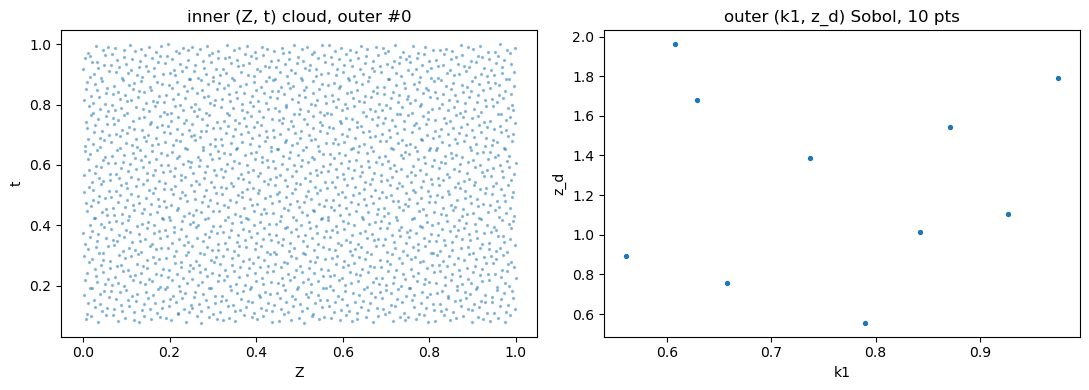

In [12]:
# quick sanity check: (Z, t) coverage for a few outer points
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
n_show = N_INNER
ax[0].scatter(X[:n_show, 2].cpu(), X[:n_show, 3].cpu(), s=2, alpha=0.4)
ax[0].set_xlabel('Z'); ax[0].set_ylabel('t'); ax[0].set_title('inner (Z, t) cloud, outer #0')
ax[1].scatter(k1_all.cpu(), zd_all.cpu(), s=8)
ax[1].set_xlabel('k1'); ax[1].set_ylabel('z_d'); ax[1].set_title(f'outer (k1, z_d) Sobol, {N_OUTER} pts')
plt.tight_layout(); plt.show()

In [13]:
# ---- Normalized training target  W = U / U0 ----
# Inputs are stored as (k1, z_d, s, tau). U0 is defined in physical (Z, t),
# so reconstruct them from the stored (s, tau) columns just for U0.
lam = 1
s_col   = X[:, 2]
tau_col = X[:, 3]
Zc = -torch.log(s_col)          # s  -> Z
Tc = (1.0 - tau_col) / tau_col  # tau -> t

U0_pts = lam * U0(Zc / lam, k2 * Tc / lam**2)
W = Y / U0_pts

print(f'W: {tuple(W.shape)}   finite: {torch.isfinite(W).all().item()}')
print(f'  W range: [{W.min():.4e}, {W.max():.4e}]')

# Final training tensors: inputs (k1, z_d, s, tau) -> W
X_train = X            # (N, 4)  columns: k1, z_d, s, tau
Y_train = W            # (N,)

W: (20480,)   finite: True
  W range: [6.5758e-01, 1.0042e+00]


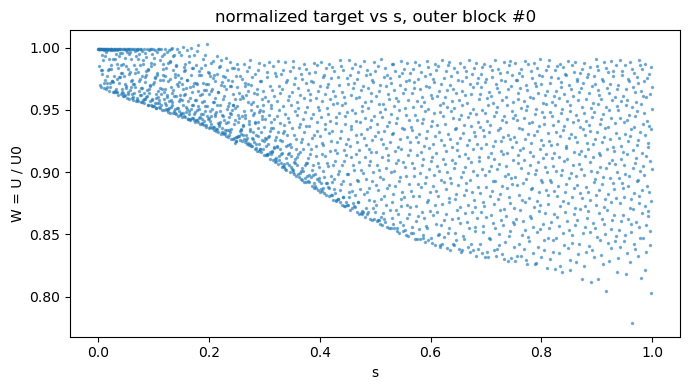

In [14]:
# sanity: target W vs s for the first outer block
blk = slice(0, N_INNER)
sb = X[blk, 2].cpu()
Wb = W[blk].cpu()
order = torch.argsort(sb)
plt.figure(figsize=(7,4))
plt.plot(sb[order], Wb[order], '.', ms=3, alpha=0.5)
plt.xlabel('s'); plt.ylabel('W = U / U0'); plt.title('normalized target vs s, outer block #0')
plt.tight_layout(); plt.show()

In [15]:
# ---- Persist the generated dataset for the NN ----
save_path = 'training_data_4d.pt'
torch.save({
    'X': X_train,                             # (N, 4)  inputs
    'Y': Y_train,                             # (N,)    target W = U/U0
    'cols':   ['k1', 'z_d', 's', 'tau'],      # input column order
    'target': 'W = U / U0',
    'domain': {'Lz': Lz, 'tf': tf, 't_min': t_min,
               'k1_lo': k1_lo, 'k1_hi': k1_hi,
               'zd_lo': zd_lo, 'zd_hi': zd_hi,
               's_lo': float(s_lo), 's_hi': float(s_hi),
               'tau_lo': float(tau_lo), 'tau_hi': float(tau_hi)},
    'sampling': {'N_outer': N_OUTER, 'N_inner': N_INNER,
                 'nz': nz, 'nt': M, 'k2': k2},
}, save_path)
print(f'saved {save_path}   X: {tuple(X_train.shape)}   Y: {tuple(Y_train.shape)}')

saved training_data_4d.pt   X: (20480, 4)   Y: (20480,)
